[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/sonder-art/ia_p26/blob/main/clase/07_optimization/notebooks/03_tarea_optimizacion.ipynb)

# Tarea 7: Optimización (20 puntos)

**Entrega:** Lunes 23 de febrero, 2026
**Formato:** Pull request en `estudiantes/<tu-usuario>/tarea_07/` + Canvas

## Instrucciones

Para **cada** problema (5 en total, 4 pts c/u):

| Pts | Qué hacer |
|:---:|-----------|
| 1 | **Formulación matemática** — escribe variables de decisión, función objetivo y restricciones en LaTeX |
| 1 | **Elección de optimizador** — elige el método/solver y explica por qué es adecuado |
| 1 | **Implementación** — completa las funciones esqueleto (las que tienen `raise NotImplementedError`) |
| 1 | **Solución y visualización** — ejecuta, reporta el resultado y visualiza |

**Reglas:**
- Completa SOLO las celdas marcadas con `raise NotImplementedError`
- NO modifiques las celdas de datos
- Escribe la matemática en LaTeX dentro de las celdas markdown indicadas
- Cada función tiene documentación con los inputs/outputs esperados

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import (minimize, minimize_scalar, linprog, milp,
                            LinearConstraint, Bounds,
                            dual_annealing, differential_evolution)

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

---
## Problema 1: Nutrición animal (4 puntos)

Un ganadero necesita formular la **dieta diaria** para su ganado. Dispone de 6 ingredientes, cada uno con un costo por kilogramo y un perfil nutricional conocido (energía, proteína, calcio, fósforo).

La dieta debe cumplir **requerimientos mínimos** de cada nutriente, y el **consumo total** debe estar entre 8 y 12 kg por animal. Cada ingrediente tiene un **límite máximo** de inclusión.

El objetivo es **minimizar el costo total** de la dieta diaria por animal.

| Ingrediente | Costo (\$/kg) | Energía (Mcal/kg) | Proteína (g/kg) | Calcio (g/kg) | Fósforo (g/kg) | Max (kg) |
|:-----------:|:------------:|:-----------------:|:---------------:|:------------:|:--------------:|:--------:|
| Maíz        | 4.5          | 3.3               | 90              | 0.3          | 2.8            | 6.0      |
| Soya        | 9.0          | 3.2               | 440             | 2.7          | 6.5            | 3.0      |
| Heno        | 2.5          | 2.0               | 80              | 4.0          | 2.0            | 5.0      |
| Melaza      | 3.0          | 2.8               | 40              | 8.0          | 0.8            | 2.0      |
| Minerales   | 15.0         | 0.0               | 0               | 200.0        | 80.0           | 0.5      |
| Salvado     | 3.5          | 2.5               | 150             | 1.5          | 12.0           | 4.0      |

**Requerimientos mínimos diarios por animal:** Energía >= 25 Mcal, Proteína >= 1000 g, Calcio >= 30 g, Fósforo >= 20 g

**Consumo total:** entre 8 y 12 kg

### 1.1 Formulacion matematica

**Variables de decisión**

Sea $$x_i \ge 0$$ la cantidad (kg) del ingrediente $$i \in \{1,\dots,6\}.$$

**Función objetivo**

$$\min_{x \in \mathbb{R}^6}\ \sum_{i=1}^{6} c_i x_i$$

**Restricciones**

Requerimientos mínimos de nutrientes (para $$k \in \{\text{Energía, Proteína, Calcio, Fósforo}\}$$):
$$\sum_{i=1}^{6} a_{k,i}\,x_i \ge r_k$$

Consumo total:
$$8 \le \sum_{i=1}^{6} x_i \le 12$$

Máximo por ingrediente:
$$0 \le x_i \le \overline{x}_i \quad \forall i$$

### 1.2 Eleccion de optimizador

**Optimizador elegido:** `scipy.optimize.linprog (method="highs")`

**Justificación (2–3 oraciones):**  
La función objetivo es lineal en $$x$$ y todas las restricciones también son lineales, por lo que el modelo es un problema de programación lineal. `linprog` con HiGHS es un solver eficiente y robusto para LPs y maneja directamente cotas y restricciones lineales.

In [21]:
# === DATOS PROBLEMA 1 (NO MODIFICAR) ===
nombres_p1 = ["Maiz", "Soya", "Heno", "Melaza", "Minerales", "Salvado"]
costos_p1 = np.array([4.5, 9.0, 2.5, 3.0, 15.0, 3.5])

# Contenido nutricional por kg: filas = [energia, proteina, calcio, fosforo]
nutrientes_p1 = np.array([
    [3.3, 3.2, 2.0, 2.8, 0.0, 2.5],   # energia (Mcal/kg)
    [90,  440, 80,  40,  0,   150],     # proteina (g/kg)
    [0.3, 2.7, 4.0, 8.0, 200, 1.5],    # calcio (g/kg)
    [2.8, 6.5, 2.0, 0.8, 80,  12.0],   # fosforo (g/kg)
])

nombres_nutrientes_p1 = ["Energia (Mcal)", "Proteina (g)", "Calcio (g)", "Fosforo (g)"]
req_min_p1 = np.array([25.0, 1000.0, 30.0, 20.0])
max_kg_p1 = np.array([6.0, 3.0, 5.0, 2.0, 0.5, 4.0])
intake_min_p1, intake_max_p1 = 8.0, 12.0

In [22]:
# === IMPLEMENTACION PROBLEMA 1 ===

def objetivo_p1(x):
    """Calcula el costo total de la dieta.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        float -- costo total de la dieta
    """
    x = np.asarray(x, dtype=float)
    return float(costos_p1 @ x)


def verificar_p1(x):
    """Verifica si la solucion cumple TODAS las restricciones.

    Args:
        x: np.array (6,) -- kg de cada ingrediente

    Returns:
        dict con:
            'factible': bool
            'nutrientes_totales': np.array (4,) -- aporte total de cada nutriente
            'intake_total': float -- kg totales
    """
    x = np.asarray(x, dtype=float)

    nutrientes_totales = nutrientes_p1 @ x  # (4,)
    intake_total = float(x.sum())

    ok_nutr = np.all(nutrientes_totales + 1e-9 >= req_min_p1)
    ok_intake = (intake_total + 1e-9 >= intake_min_p1) and (intake_total - 1e-9 <= intake_max_p1)
    ok_bounds = np.all(x + 1e-9 >= 0) and np.all(x - 1e-9 <= max_kg_p1)

    factible = bool(ok_nutr and ok_intake and ok_bounds)

    return {
        "factible": factible,
        "nutrientes_totales": nutrientes_totales,
        "intake_total": intake_total
    }


def resolver_p1():
    """Resuelve el problema de nutricion animal.

    Usa linprog porque es un LP:
    min c^T x s.t. A_ub x <= b_ub y bounds.

    Returns:
        x_opt: np.array (6,) -- kg optimos
        costo_opt: float -- costo minimo
    """
    # linprog: min c^T x, s.t. A_ub x <= b_ub
    c = costos_p1

    A_ub = []
    b_ub = []

    # Nutrientes >= req  ->  -A x <= -req
    A_ub.append(-nutrientes_p1)   # (4,6)
    b_ub.append(-req_min_p1)      # (4,)

    # Intake <= intake_max
    A_ub.append(np.ones((1, len(c))))
    b_ub.append(np.array([intake_max_p1]))

    # Intake >= intake_min  ->  -sum x <= -intake_min
    A_ub.append(-np.ones((1, len(c))))
    b_ub.append(np.array([-intake_min_p1]))

    A_ub = np.vstack(A_ub)
    b_ub = np.concatenate(b_ub)

    bounds = [(0.0, float(mx)) for mx in max_kg_p1]

    res = linprog(c=c, A_ub=A_ub, b_ub=b_ub, bounds=bounds, method="highs")
    if not res.success:
        raise RuntimeError(f"linprog fallo: {res.message}")

    x_opt = res.x
    costo_opt = float(res.fun)
    return x_opt, costo_opt

Solucion P1:
  Maiz: 0.407 kg
  Soya: 0.000 kg
  Heno: 5.000 kg
  Melaza: 2.000 kg
  Minerales: 0.000 kg
  Salvado: 3.222 kg
Costo total: $31.61
Intake total: 10.63 kg
Factible: True


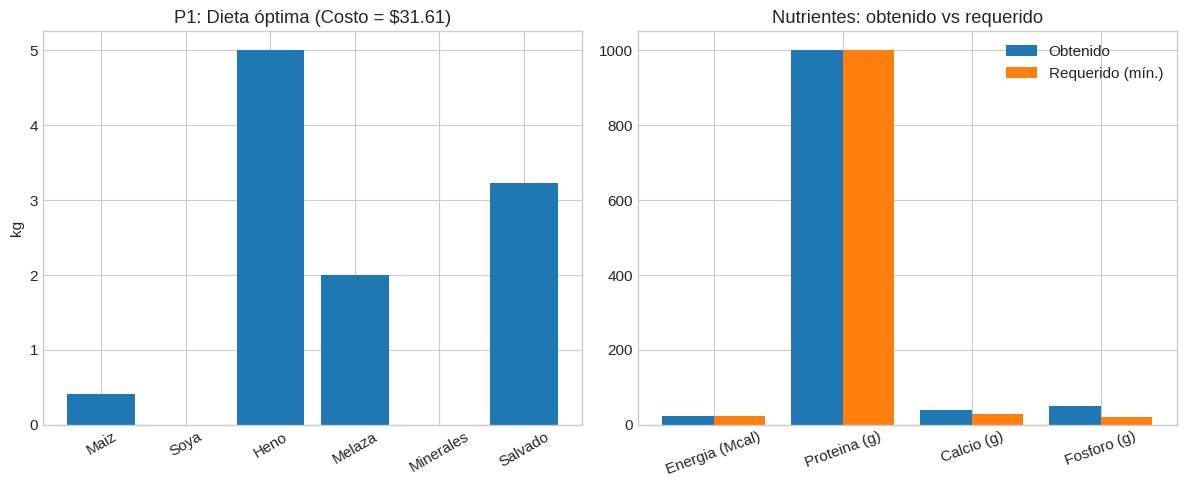

In [23]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 1 ===

def plot_p1(x_opt, costo_opt):
    """Visualiza la solucion del problema de nutricion.

    - Panel 1: Barras con kg de cada ingrediente
    - Panel 2: Barras comparando nutrientes obtenidos vs requeridos
    """
    x_opt = np.asarray(x_opt, dtype=float)
    info = verificar_p1(x_opt)
    nutrientes_tot = info["nutrientes_totales"]

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Panel 1: kg por ingrediente
    axes[0].bar(nombres_p1, x_opt)
    axes[0].set_title(f"P1: Dieta óptima (Costo = ${costo_opt:.2f})")
    axes[0].set_ylabel("kg")
    axes[0].tick_params(axis="x", rotation=30)

    # Panel 2: Nutrientes obtenidos vs requeridos
    idx = np.arange(len(nombres_nutrientes_p1))
    width = 0.4
    axes[1].bar(idx - width/2, nutrientes_tot, width, label="Obtenido")
    axes[1].bar(idx + width/2, req_min_p1, width, label="Requerido (mín.)")
    axes[1].set_xticks(idx)
    axes[1].set_xticklabels(nombres_nutrientes_p1, rotation=20)
    axes[1].set_title("Nutrientes: obtenido vs requerido")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


# Resolver y visualizar
x_opt_p1, costo_opt_p1 = resolver_p1()
info_p1 = verificar_p1(x_opt_p1)

print("Solucion P1:")
for nombre, kg in zip(nombres_p1, x_opt_p1):
    print(f"  {nombre}: {kg:.3f} kg")
print(f"Costo total: ${costo_opt_p1:.2f}")
print(f"Intake total: {info_p1['intake_total']:.2f} kg")
print(f"Factible: {info_p1['factible']}")

plot_p1(x_opt_p1, costo_opt_p1)

---
## Problema 2: Portafolio de inversion (4 puntos)

Un inversionista tiene capital para distribuir entre 5 activos financieros. Cada activo tiene un **rendimiento esperado** y una **covarianza** conocida con los demas activos (ver datos).

El objetivo es **minimizar el riesgo** del portafolio (medido como la varianza del rendimiento), sujeto a:
- El rendimiento esperado del portafolio debe ser **al menos 8%**
- Todo el capital debe invertirse (las proporciones suman 1)
- No se permiten ventas en corto (todas las proporciones >= 0)
- Ningun activo puede representar mas del **40%** del portafolio

### 2.1 Formulacion matematica

**Variables de decisión**

Sea $$w_i \ge 0$$ la proporción invertida en el activo $$i \in \{1,\dots,5\}.$$

**Función objetivo (riesgo/varianza)**

$$\min_{w \in \mathbb{R}^5}\ w^\top \Sigma w$$

**Restricciones**

Todo el capital se invierte:
$$\sum_{i=1}^{5} w_i = 1$$

Rendimiento mínimo:
$$\sum_{i=1}^{5} \mu_i w_i \ge 0.08$$

No ventas en corto y límite por activo:
$$0 \le w_i \le 0.40 \quad \forall i$$

### 2.2 Eleccion de optimizador
**Optimizador elegido:** `scipy.optimize.minimize (method="SLSQP")`

**Justificación (2–3 oraciones):**  
El objetivo $$w^\top \Sigma w$$ es una función cuadrática suave y las restricciones (igualdad, desigualdad y cotas) son lineales. `SLSQP` está diseñado para optimización no lineal con restricciones y funciona bien en problemas pequeños/medianos como este.

In [24]:
# === DATOS PROBLEMA 2 (NO MODIFICAR) ===
activos_p2 = ["Bonos gob.", "Acciones tech", "Bienes raices", "Materias primas", "Mercados emergentes"]
rendimientos_p2 = np.array([0.03, 0.14, 0.08, 0.11, 0.16])

cov_p2 = np.array([
    [0.0004, 0.0002, 0.0001, 0.0000, 0.0003],
    [0.0002, 0.0100, 0.0030, 0.0050, 0.0080],
    [0.0001, 0.0030, 0.0025, 0.0015, 0.0020],
    [0.0000, 0.0050, 0.0015, 0.0064, 0.0040],
    [0.0003, 0.0080, 0.0020, 0.0040, 0.0144],
])

retorno_minimo_p2 = 0.08
max_por_activo_p2 = 0.40

In [25]:
# === IMPLEMENTACION PROBLEMA 2 ===

def objetivo_p2(w):
    """Varianza del portafolio: w^T Σ w."""
    w = np.asarray(w, dtype=float)
    return float(w.T @ cov_p2 @ w)


def verificar_p2(w):
    """Checa suma=1, retorno>=min, 0<=w<=max."""
    w = np.asarray(w, dtype=float)

    suma = float(w.sum())
    rendimiento = float(rendimientos_p2 @ w)
    varianza = float(w.T @ cov_p2 @ w)

    ok_suma = abs(suma - 1.0) <= 1e-6
    ok_ret = rendimiento + 1e-9 >= retorno_minimo_p2
    ok_bounds = np.all(w + 1e-9 >= 0) and np.all(w - 1e-9 <= max_por_activo_p2)

    return {
        "factible": bool(ok_suma and ok_ret and ok_bounds),
        "rendimiento": rendimiento,
        "varianza": varianza,
        "suma_pesos": suma
    }


def resolver_p2():
    """Minimiza riesgo sujeto a restricciones usando SLSQP (maneja eq + ineq + bounds)."""
    # Constraints para SLSQP: eq -> fun(w)=0, ineq -> fun(w) >= 0
    cons = [
        {"type": "eq", "fun": lambda w: np.sum(w) - 1.0},
        {"type": "ineq", "fun": lambda w: (rendimientos_p2 @ w) - retorno_minimo_p2},
    ]

    bounds = [(0.0, float(max_por_activo_p2)) for _ in range(len(rendimientos_p2))]

    # w0: inicial factible "casi" (SLSQP ajusta)
    w0 = np.ones(len(rendimientos_p2)) / len(rendimientos_p2)

    res = minimize(
        objetivo_p2,
        w0,
        method="SLSQP",
        bounds=bounds,
        constraints=cons,
        options={"maxiter": 2000}
    )
    if not res.success:
        raise RuntimeError(f"minimize SLSQP fallo: {res.message}")

    w_opt = np.asarray(res.x, dtype=float)

    # (opcional) normalizar por estabilidad numérica
    w_opt = np.clip(w_opt, 0.0, max_por_activo_p2)
    w_opt = w_opt / w_opt.sum()

    var_opt = float(w_opt.T @ cov_p2 @ w_opt)
    return w_opt, var_opt

Solucion P2:
  Bonos gob.: 35.7%
  Acciones tech: 9.9%
  Bienes raices: 27.4%
  Materias primas: 19.4%
  Mercados emergentes: 7.6%
Rendimiento esperado: 8.00%
Varianza: 0.001548
Desv. estandar: 3.93%
Suma pesos: 1.000000
Factible: True


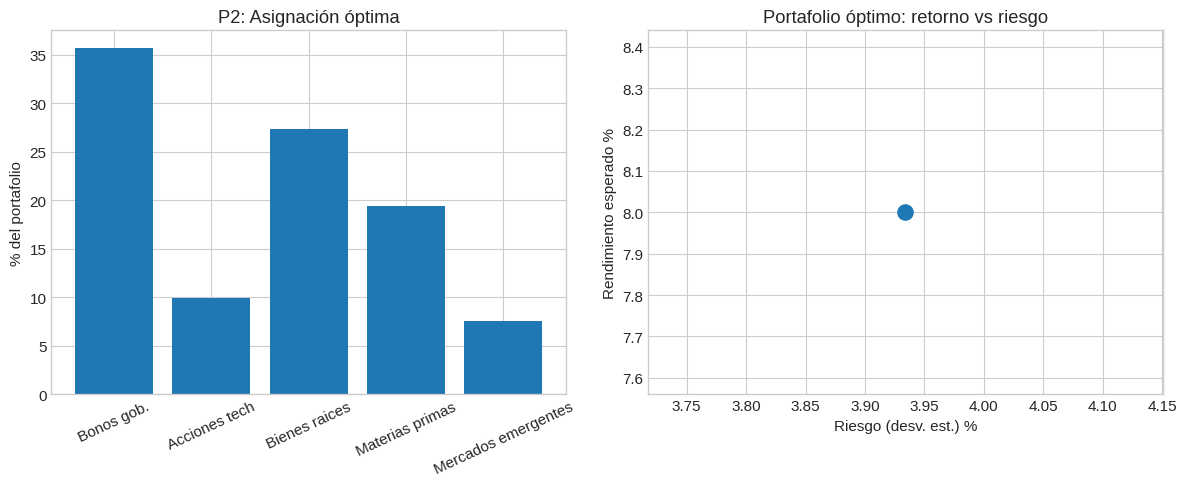

In [26]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 2 ===

def plot_p2(w_opt, varianza_opt):
    """- Panel 1: % por activo
       - Panel 2: punto retorno vs riesgo
    """
    w_opt = np.asarray(w_opt, dtype=float)
    info = verificar_p2(w_opt)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Panel 1: asignación
    axes[0].bar(activos_p2, w_opt * 100)
    axes[0].set_ylabel("% del portafolio")
    axes[0].set_title("P2: Asignación óptima")
    axes[0].tick_params(axis="x", rotation=25)

    # Panel 2: retorno vs riesgo (un punto)
    riesgo = float(np.sqrt(varianza_opt))
    retorno = float(info["rendimiento"])

    axes[1].scatter([riesgo * 100], [retorno * 100], s=120)
    axes[1].set_xlabel("Riesgo (desv. est.) %")
    axes[1].set_ylabel("Rendimiento esperado %")
    axes[1].set_title("Portafolio óptimo: retorno vs riesgo")

    plt.tight_layout()
    plt.show()


#  Ejecutar
w_opt_p2, var_opt_p2 = resolver_p2()
info_p2 = verificar_p2(w_opt_p2)

print("Solucion P2:")
for activo, w in zip(activos_p2, w_opt_p2):
    print(f"  {activo}: {w*100:.1f}%")
print(f"Rendimiento esperado: {info_p2['rendimiento']*100:.2f}%")
print(f"Varianza: {var_opt_p2:.6f}")
print(f"Desv. estandar: {np.sqrt(var_opt_p2)*100:.2f}%")
print(f"Suma pesos: {info_p2['suma_pesos']:.6f}")
print(f"Factible: {info_p2['factible']}")

plot_p2(w_opt_p2, var_opt_p2)

---
## Problema 3: Cobertura con antenas (4 puntos)

Una empresa de telecomunicaciones necesita dar cobertura de senal en **10 zonas** de una ciudad. Existen **7 ubicaciones** posibles para instalar torres de transmision. Cada torre tiene un costo de construccion y cubre un conjunto especifico de zonas (ver tabla).

El objetivo es **seleccionar que torres construir** para cubrir **todas las zonas** al **minimo costo** total. Cada torre se construye completamente o no se construye (decision binaria).

| Torre | Costo (miles \$) | Zonas que cubre |
|:-----:|:----------------:|:---------------:|
| T1    | 50               | 1, 2, 3         |
| T2    | 80               | 2, 3, 4, 5      |
| T3    | 60               | 4, 5, 6         |
| T4    | 70               | 5, 6, 7, 8      |
| T5    | 90               | 7, 8, 9, 10     |
| T6    | 40               | 1, 9, 10        |
| T7    | 75               | 3, 6, 7         |

### 3.1 Formulacion matematica
**Variables de decisión**

Sea $$y_i \in \{0,1\}$$ donde $$y_i=1$$ si se construye la torre $$i \in \{1,\dots,7\}$$ y $$y_i=0$$ si no.

**Función objetivo**

$$\min_{y}\ \sum_{i=1}^{7} c_i y_i$$

**Restricciones**

Cobertura total (para cada zona $$j \in \{1,\dots,10\}$$):
$$\sum_{i=1}^{7} a_{i,j}\,y_i \ge 1$$
donde $$a_{i,j}=1$$ si la torre $$i$$ cubre la zona $$j$$.

### 3.2 Eleccion de optimizador

**Optimizador elegido:** `scipy.optimize.milp`

**Justificación (2–3 oraciones):**  
El modelo tiene variables binarias $$y_i \in \{0,1\}$$ y restricciones lineales de cobertura, por lo que es programación entera binaria (set cover). `milp` permite resolver este tipo de problemas de manera exacta bajo un marco MILP.

In [29]:
# === DATOS PROBLEMA 3 (NO MODIFICAR) ===
n_torres_p3 = 7
n_zonas_p3 = 10
costos_torres_p3 = np.array([50, 80, 60, 70, 90, 40, 75])
nombres_torres_p3 = [f"T{i+1}" for i in range(n_torres_p3)]

# cobertura_p3[i, j] = 1 si torre i cubre zona j+1
cobertura_p3 = np.array([
    [1, 1, 1, 0, 0, 0, 0, 0, 0, 0],  # T1: zonas 1,2,3
    [0, 1, 1, 1, 1, 0, 0, 0, 0, 0],  # T2: zonas 2,3,4,5
    [0, 0, 0, 1, 1, 1, 0, 0, 0, 0],  # T3: zonas 4,5,6
    [0, 0, 0, 0, 1, 1, 1, 1, 0, 0],  # T4: zonas 5,6,7,8
    [0, 0, 0, 0, 0, 0, 1, 1, 1, 1],  # T5: zonas 7,8,9,10
    [1, 0, 0, 0, 0, 0, 0, 0, 1, 1],  # T6: zonas 1,9,10
    [0, 0, 1, 0, 0, 1, 1, 0, 0, 0],  # T7: zonas 3,6,7
])

In [30]:
# === IMPLEMENTACION PROBLEMA 3 ===

def objetivo_p3(y):
    """Costo total de torres seleccionadas."""
    y = np.asarray(y, dtype=float)
    return float(costos_torres_p3 @ y)


def verificar_p3(y):
    """Verifica si todas las zonas quedan cubiertas."""
    y = np.asarray(y, dtype=float)

    # cobertura por zona: suma de torres seleccionadas que cubren esa zona
    cub = y @ cobertura_p3  # (10,)
    zonas_cubiertas = [j+1 for j in range(n_zonas_p3) if cub[j] >= 1 - 1e-9]
    zonas_sin = [j+1 for j in range(n_zonas_p3) if cub[j] < 1 - 1e-9]

    return {
        "factible": len(zonas_sin) == 0,
        "zonas_cubiertas": zonas_cubiertas,
        "zonas_sin_cubrir": zonas_sin
    }


def resolver_p3():
    """Set cover binario con scipy.optimize.milp."""
    c = costos_torres_p3.astype(float)

    # Restricción: A @ y >= 1 (para cada zona)
    A = cobertura_p3.T.astype(float)  # (10,7)
    cons = LinearConstraint(A, lb=np.ones(n_zonas_p3), ub=np.full(n_zonas_p3, np.inf))

    bounds = Bounds(lb=np.zeros(n_torres_p3), ub=np.ones(n_torres_p3))
    integrality = np.ones(n_torres_p3, dtype=int)  # todas binarias/enteras

    res = milp(c=c, constraints=cons, integrality=integrality, bounds=bounds)
    if res.status != 0:
        raise RuntimeError(f"milp fallo (status={res.status}): {res.message}")

    # MILP puede devolver valores ~0/1 en float
    y_opt = np.asarray(res.x, dtype=float)
    y_opt = (y_opt > 0.5).astype(float)

    costo_opt = float(c @ y_opt)
    return y_opt, costo_opt

Solucion P3:
  T2: Construir (costo=$80k, cubre zonas [2, 3, 4, 5])
  T4: Construir (costo=$70k, cubre zonas [5, 6, 7, 8])
  T6: Construir (costo=$40k, cubre zonas [1, 9, 10])
Costo total: $190k
Factible: True
Zonas sin cubrir: []


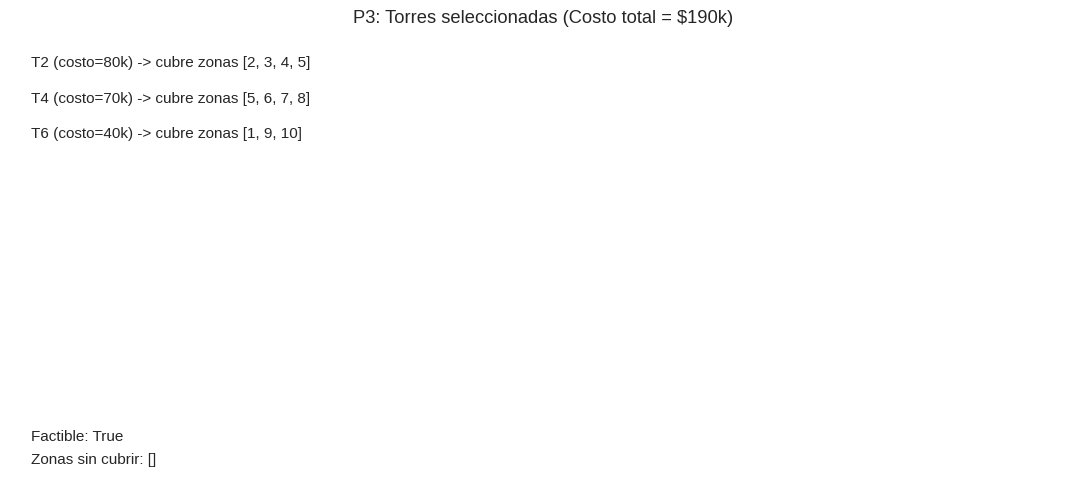

In [31]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 3 ===

def plot_p3(y_opt, costo_opt):
    """Muestra qué torres se seleccionaron y qué zonas cubren."""
    y_opt = np.asarray(y_opt, dtype=float)
    seleccion = [i for i in range(n_torres_p3) if y_opt[i] > 0.5]

    fig, ax = plt.subplots(figsize=(11, 5))
    ax.set_title(f"P3: Torres seleccionadas (Costo total = ${costo_opt:.0f}k)")
    ax.set_axis_off()

    y0 = 0.92
    dy = 0.08

    if len(seleccion) == 0:
        ax.text(0.02, y0, "No se seleccionó ninguna torre (algo salió mal).", transform=ax.transAxes)
    else:
        for k, i in enumerate(seleccion):
            zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
            ax.text(
                0.02, y0 - k*dy,
                f"{nombres_torres_p3[i]} (costo={costos_torres_p3[i]}k) -> cubre zonas {zonas}",
                transform=ax.transAxes
            )

    # cobertura final
    info = verificar_p3(y_opt)
    ax.text(0.02, 0.08, f"Factible: {info['factible']}", transform=ax.transAxes)
    ax.text(0.02, 0.03, f"Zonas sin cubrir: {info['zonas_sin_cubrir']}", transform=ax.transAxes)

    plt.tight_layout()
    plt.show()


# Ejecutar
y_opt_p3, costo_opt_p3 = resolver_p3()
info_p3 = verificar_p3(y_opt_p3)

print("Solucion P3:")
for i, (nombre, sel) in enumerate(zip(nombres_torres_p3, y_opt_p3)):
    if sel > 0.5:
        zonas = [j+1 for j in range(n_zonas_p3) if cobertura_p3[i, j] == 1]
        print(f"  {nombre}: Construir (costo=${costos_torres_p3[i]:.0f}k, cubre zonas {zonas})")

print(f"Costo total: ${costo_opt_p3:.0f}k")
print(f"Factible: {info_p3['factible']}")
print(f"Zonas sin cubrir: {info_p3['zonas_sin_cubrir']}")

plot_p3(y_opt_p3, costo_opt_p3)

---
## Problema 4: Calibracion de sensor (4 puntos)

Un ingeniero necesita calibrar un sensor cuya respuesta sigue el modelo:

$$y(t) = a \cdot \sin(b \cdot t + c) + d \cdot e^{-0.1 \cdot t}$$

donde $a, b, c, d$ son parametros desconocidos y $t$ es la posicion del sensor.

Se tienen **20 mediciones** del sensor en posiciones conocidas (ver datos). El objetivo es encontrar los parametros $a, b, c, d$ que **minimicen el error** entre las predicciones del modelo y las mediciones observadas.

**Nota:** El paisaje de error tiene **multiples minimos locales** debido a los terminos trigonometricos.

**Cotas de los parametros:** $a \in [0, 5]$, $b \in [0, 10]$, $c \in [0, 2\pi]$, $d \in [-3, 3]$

### 4.1 Formulacion matematica
**Variables de decisión**

Sea $$\theta = (a,b,c,d)$$ el vector de parámetros.

**Función objetivo (error cuadrático total)**

$$\min_{\theta}\ \sum_{i=1}^{20}\left(y_i - \left[a\sin(bt_i+c) + d e^{-0.1t_i}\right]\right)^2$$

**Restricciones (cotas)**

$$a \in [0,5],\quad b \in [0,10],\quad c \in [0,2\pi],\quad d \in [-3,3]$$

### 4.2 Eleccion de optimizador

**Optimizador elegido:** `scipy.optimize.differential_evolution`

**Justificación (2–3 oraciones):**  
El término sinusoidal genera un paisaje con múltiples mínimos locales, por lo que un método local puede quedarse atrapado. `differential_evolution` es un método global que solo requiere evaluar la función objetivo y trabaja naturalmente con cotas.

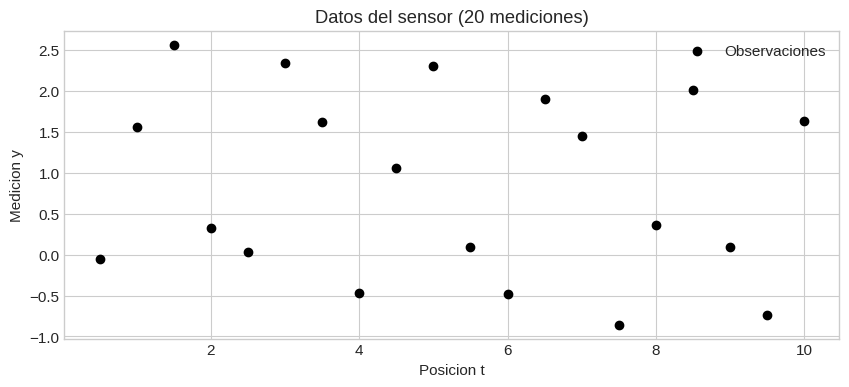

In [14]:
# === DATOS PROBLEMA 4 (NO MODIFICAR) ===

def modelo_sensor(t, params):
    """Modelo del sensor: y = a*sin(b*t + c) + d*exp(-0.1*t)

    Args:
        t: np.array -- posiciones
        params: np.array (4,) -- [a, b, c, d]

    Returns:
        np.array -- predicciones del modelo
    """
    a, b, c, d = params
    return a * np.sin(b * t + c) + d * np.exp(-0.1 * t)

# Posiciones de medicion
t_obs_p4 = np.linspace(0.5, 10.0, 20)

# Mediciones observadas (generadas con parametros ocultos + ruido)
_rng_p4 = np.random.default_rng(2026)
_params_ocultos = _rng_p4.uniform([1, 1, 0, 0.5], [4, 5, 2*np.pi, 3])
y_obs_p4 = modelo_sensor(t_obs_p4, _params_ocultos) + _rng_p4.normal(0, 0.2, 20)
del _rng_p4, _params_ocultos

bounds_p4 = [(0, 5), (0, 10), (0, 2*np.pi), (-3, 3)]

# Visualizar los datos
plt.figure(figsize=(10, 4))
plt.scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
plt.xlabel("Posicion t"); plt.ylabel("Medicion y")
plt.title("Datos del sensor (20 mediciones)")
plt.legend(); plt.show()

In [32]:
# === IMPLEMENTACION PROBLEMA 4 ===

def objetivo_p4(params):
    """SSE = sum (y_hat(t_i; params) - y_obs_i)^2"""
    params = np.asarray(params, dtype=float)
    y_pred = modelo_sensor(t_obs_p4, params)
    resid = y_pred - y_obs_p4
    return float(np.sum(resid**2))


def resolver_p4():
    """Optimización black-box multimodal:
       1) global: Differential Evolution
       2) refinamiento local: L-BFGS-B con bounds
    """
    # Global
    res_de = differential_evolution(
        objetivo_p4,
        bounds=bounds_p4,
        seed=2026,
        polish=False  # nosotros hacemos el "polish" con minimize
    )

    x0 = np.asarray(res_de.x, dtype=float)

    # Local
    res_local = minimize(
        objetivo_p4,
        x0,
        method="L-BFGS-B",
        bounds=bounds_p4,
        options={"maxiter": 5000}
    )

    if res_local.success:
        return np.asarray(res_local.x, dtype=float), float(res_local.fun)

    # Si el local falla, regresa DE (pero no te deja sin respuesta)
    return np.asarray(res_de.x, dtype=float), float(res_de.fun)

Solucion P4:
  a = 1.5089
  b = 3.5530
  c = 2.9058
  d = 1.4254
Error (SSE): 0.088386


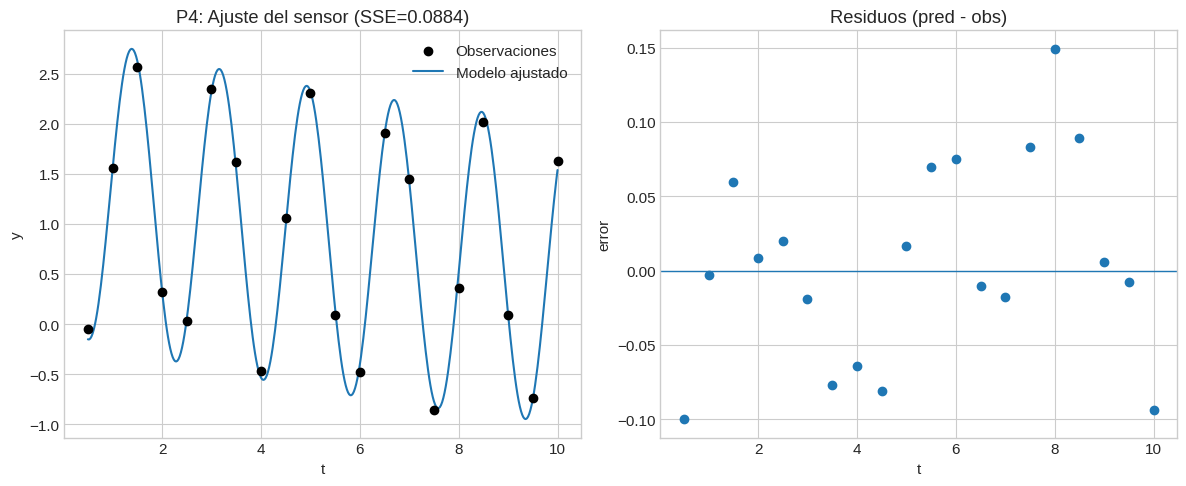

In [33]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 4 ===

def plot_p4(params_opt, error_opt):
    """- Panel 1: datos + curva ajustada
       - Panel 2: residuos en t_obs
    """
    params_opt = np.asarray(params_opt, dtype=float)

    t_grid = np.linspace(t_obs_p4.min(), t_obs_p4.max(), 400)
    y_fit_grid = modelo_sensor(t_grid, params_opt)
    y_fit_obs = modelo_sensor(t_obs_p4, params_opt)
    resid = y_fit_obs - y_obs_p4

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Panel 1: datos + curva
    axes[0].scatter(t_obs_p4, y_obs_p4, color="black", zorder=5, label="Observaciones")
    axes[0].plot(t_grid, y_fit_grid, zorder=3, label="Modelo ajustado")
    axes[0].set_title(f"P4: Ajuste del sensor (SSE={error_opt:.4f})")
    axes[0].set_xlabel("t")
    axes[0].set_ylabel("y")
    axes[0].legend()

    # Panel 2: residuos
    axes[1].axhline(0, linewidth=1)
    axes[1].scatter(t_obs_p4, resid)
    axes[1].set_title("Residuos (pred - obs)")
    axes[1].set_xlabel("t")
    axes[1].set_ylabel("error")

    plt.tight_layout()
    plt.show()


# Ejecutar
params_opt_p4, error_opt_p4 = resolver_p4()

print("Solucion P4:")
print(f"  a = {params_opt_p4[0]:.4f}")
print(f"  b = {params_opt_p4[1]:.4f}")
print(f"  c = {params_opt_p4[2]:.4f}")
print(f"  d = {params_opt_p4[3]:.4f}")
print(f"Error (SSE): {error_opt_p4:.6f}")

plot_p4(params_opt_p4, error_opt_p4)

---
## Problema 5: Red de distribucion (4 puntos)

Una empresa de logistica considera abrir centros de distribucion (CDs) en **4 ciudades** posibles para atender a **6 clientes**. Cada CD tiene un **costo fijo** de apertura, una **capacidad maxima**, y un **costo de envio por unidad** a cada cliente. Cada cliente tiene una **demanda** que debe ser satisfecha completamente.

La empresa debe decidir:
1. **Que CDs abrir** (decision binaria: abrir o no)
2. **Cuantas unidades enviar** de cada CD abierto a cada cliente (decision continua)

El objetivo es **minimizar el costo total** (costos fijos de apertura + costos de envio).

| CD | Ciudad      | Costo fijo (miles \$) | Capacidad |
|:--:|:-----------:|:--------------------:|:---------:|
| 1  | Guadalajara | 800                  | 500       |
| 2  | Monterrey   | 700                  | 400       |
| 3  | CDMX        | 1000                 | 600       |
| 4  | Merida      | 600                  | 350       |

| Cliente | C1  | C2 | C3  | C4  | C5  | C6  |
|:-------:|:---:|:--:|:---:|:---:|:---:|:---:|
| Demanda | 120 | 80 | 200 | 150 | 100 | 180 |

**Costos de envio** (\$ por unidad):

|      | C1 | C2 | C3 | C4 | C5 | C6 |
|:----:|:--:|:--:|:--:|:--:|:--:|:--:|
| GDL  | 4  | 8  | 5  | 9  | 7  | 6  |
| MTY  | 7  | 3  | 6  | 8  | 4  | 9  |
| CDMX | 5  | 6  | 3  | 4  | 8  | 5  |
| MER  | 9  | 7  | 8  | 3  | 6  | 4  |

### 5.1 Formulacion matematica
**Variables de decisión**

$$y_i \in \{0,1\}$$ indica si se abre el centro de distribución (CD) $$i \in \{1,\dots,4\}$$.

$$x_{i,j} \ge 0$$ es la cantidad enviada del CD $$i$$ al cliente $$j \in \{1,\dots,6\}$$.

**Función objetivo**

$$\min\ \sum_{i=1}^{4} F_i y_i + \sum_{i=1}^{4}\sum_{j=1}^{6} c_{i,j}x_{i,j}$$

**Restricciones**

Demanda completa (para cada cliente $$j$$):
$$\sum_{i=1}^{4} x_{i,j} = d_j$$

Capacidad y apertura (para cada CD $$i$$):
$$\sum_{j=1}^{6} x_{i,j} \le \text{Cap}_i\,y_i$$

No negatividad y binariedad:
$$x_{i,j}\ge 0,\quad y_i \in \{0,1\}$$

### 5.2 Eleccion de optimizador

**Optimizador elegido:** `scipy.optimize.milp`

**Justificación (2–3 oraciones):**  
Este problema combina decisiones binarias (abrir CDs) con variables continuas (envíos), por lo que es un MILP. `milp` permite modelar ambos tipos de variables y restricciones lineales, incluyendo el enlace capacidad–apertura.

In [34]:
# === DATOS PROBLEMA 5 (NO MODIFICAR) ===
ciudades_p5 = ["Guadalajara", "Monterrey", "CDMX", "Merida"]
n_cds_p5 = 4
n_clientes_p5 = 6

costos_fijos_p5 = np.array([800, 700, 1000, 600])    # miles $
capacidades_p5 = np.array([500, 400, 600, 350])
demandas_p5 = np.array([120, 80, 200, 150, 100, 180])

# costos_envio_p5[i, j] = costo de enviar 1 unidad de CD i a cliente j
costos_envio_p5 = np.array([
    [4, 8, 5, 9, 7, 6],   # Guadalajara
    [7, 3, 6, 8, 4, 9],   # Monterrey
    [5, 6, 3, 4, 8, 5],   # CDMX
    [9, 7, 8, 3, 6, 4],   # Merida
])

In [35]:
# === IMPLEMENTACION PROBLEMA 5 ===

def objetivo_p5(y, X):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)
    # costos fijos en miles $, costos envío en $ -> convertir envío a miles dividiendo entre 1000
    fijo = float(costos_fijos_p5 @ y)
    envio = float(np.sum(costos_envio_p5 * X) / 1000.0)
    return fijo + envio


def verificar_p5(y, X):
    y = np.asarray(y, dtype=float)
    X = np.asarray(X, dtype=float)

    demanda_recibida = X.sum(axis=0)  # (6,)
    capacidad_usada = X.sum(axis=1)   # (4,)

    # demandas deben cumplirse EXACTO
    ok_demanda = np.allclose(demanda_recibida, demandas_p5, atol=1e-6)

    # capacidad: sum_j x_ij <= cap_i * y_i
    ok_cap = np.all(capacidad_usada - 1e-9 <= capacidades_p5 * y)

    # no negatividad envíos
    ok_nonneg = np.all(X + 1e-9 >= 0)

    # y binaria relajada en verificación (pero MILP la deja 0/1)
    ok_y = np.all((y >= -1e-9) & (y <= 1 + 1e-9))

    return {
        "factible": bool(ok_demanda and ok_cap and ok_nonneg and ok_y),
        "demanda_cumplida": demanda_recibida,
        "capacidad_usada": capacidad_usada
    }


def resolver_p5():
    """
    z = [y_1..y_4, x_11..x_1,6, x_21..x_2,6, ..., x_41..x_4,6]
    y_i binarias, x_ij continuas >= 0
    """
    n_y = n_cds_p5
    n_x = n_cds_p5 * n_clientes_p5
    n = n_y + n_x

    # Objetivo: min fijo + envio
    c = np.zeros(n, dtype=float)
    c[:n_y] = costos_fijos_p5                        # miles $
    c[n_y:] = costos_envio_p5.flatten() / 1000.0     # miles $ por unidad

    # ===== Restricciones de demanda (igualdad) =====
    # para cada cliente j: sum_i x_{i,j} = demanda_j
    A_eq = np.zeros((n_clientes_p5, n), dtype=float)
    for j in range(n_clientes_p5):
        for i in range(n_cds_p5):
            idx_x = n_y + i * n_clientes_p5 + j
            A_eq[j, idx_x] = 1.0
    b_eq = demandas_p5.astype(float)
    cons_eq = LinearConstraint(A_eq, lb=b_eq, ub=b_eq)

    # ===== Restricciones de capacidad =====
    # para cada CD i: sum_j x_{i,j} - cap_i*y_i <= 0
    A_ub = np.zeros((n_cds_p5, n), dtype=float)
    for i in range(n_cds_p5):
        A_ub[i, i] = -capacidades_p5[i]  # coeficiente de y_i
        for j in range(n_clientes_p5):
            idx_x = n_y + i * n_clientes_p5 + j
            A_ub[i, idx_x] = 1.0
    cons_cap = LinearConstraint(A_ub, lb=-np.inf*np.ones(n_cds_p5), ub=np.zeros(n_cds_p5))

    # ===== Bounds =====
    lb = np.zeros(n, dtype=float)
    ub = np.full(n, np.inf, dtype=float)
    ub[:n_y] = 1.0  # y_i ∈ [0,1]
    bounds = Bounds(lb=lb, ub=ub)

    # ===== Integrality =====
    integrality = np.zeros(n, dtype=int)
    integrality[:n_y] = 1  # y binarias/enteras, x continuas

    res = milp(c=c, constraints=[cons_eq, cons_cap], integrality=integrality, bounds=bounds)
    if res.status != 0:
        raise RuntimeError(f"milp fallo (status={res.status}): {res.message}")

    z = np.asarray(res.x, dtype=float)
    y_opt = z[:n_y]
    X_opt = z[n_y:].reshape(n_cds_p5, n_clientes_p5)

    costo_opt = objetivo_p5(y_opt, X_opt)
    return y_opt, X_opt, float(costo_opt)

Solucion P5:
  Guadalajara: ABIERTO (480/500 unidades)
    -> Cliente C1: 120 unidades
    -> Cliente C2: 80 unidades
    -> Cliente C3: 200 unidades
    -> Cliente C5: 80 unidades
  Monterrey: CERRADO
  CDMX: CERRADO
  Merida: ABIERTO (350/350 unidades)
    -> Cliente C4: 150 unidades
    -> Cliente C5: 20 unidades
    -> Cliente C6: 180 unidades
Costo total: $1404k
Factible: True
Demanda recibida (por cliente): [120.  80. 200. 150. 100. 180.]
Capacidad usada (por CD): [480.   0.   0. 350.]


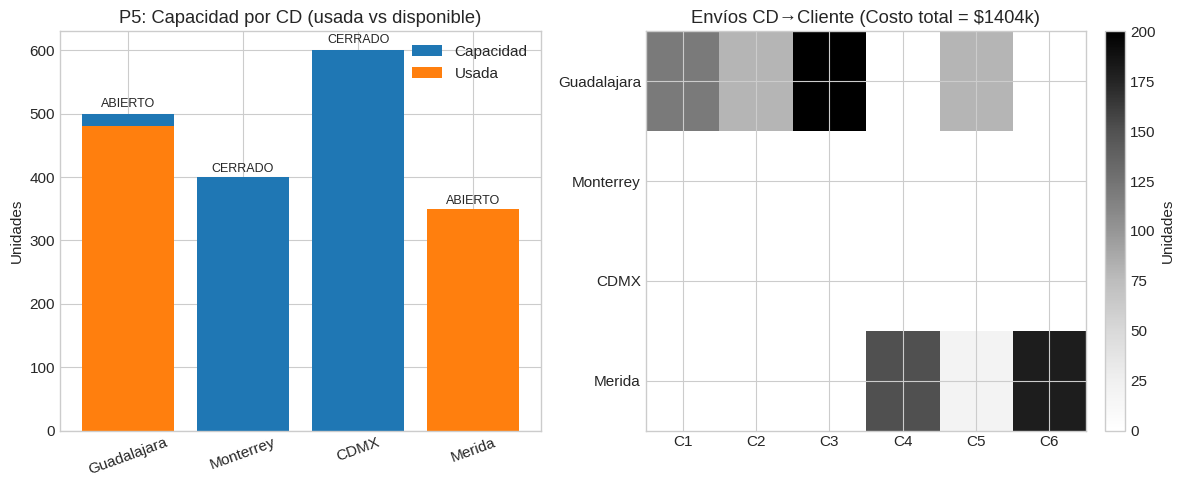

In [36]:
# === EJECUTAR Y VISUALIZAR PROBLEMA 5 ===

def plot_p5(y_opt, X_opt, costo_opt):
    y_opt = np.asarray(y_opt, dtype=float)
    X_opt = np.asarray(X_opt, dtype=float)

    cap_usada = X_opt.sum(axis=1)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Panel 1: capacidad usada vs disponible (y si está abierto)
    axes[0].bar(ciudades_p5, capacidades_p5, label="Capacidad")
    axes[0].bar(ciudades_p5, cap_usada, label="Usada")
    axes[0].set_title("P5: Capacidad por CD (usada vs disponible)")
    axes[0].set_ylabel("Unidades")
    axes[0].legend()
    axes[0].tick_params(axis="x", rotation=20)

    # marca abiertos/cerrados
    abiertos = (y_opt > 0.5)
    for i, abierto in enumerate(abiertos):
        tag = "ABIERTO" if abierto else "CERRADO"
        axes[0].text(i, capacidades_p5[i] * 1.02, tag, ha="center", fontsize=9)

    # Panel 2: heatmap de envíos
    im = axes[1].imshow(X_opt, aspect="auto")
    axes[1].set_title(f"Envíos CD→Cliente (Costo total = ${costo_opt:.0f}k)")
    axes[1].set_yticks(np.arange(n_cds_p5))
    axes[1].set_yticklabels(ciudades_p5)
    axes[1].set_xticks(np.arange(n_clientes_p5))
    axes[1].set_xticklabels([f"C{j+1}" for j in range(n_clientes_p5)])
    plt.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04, label="Unidades")

    plt.tight_layout()
    plt.show()


# Ejecutar
y_opt_p5, X_opt_p5, costo_opt_p5 = resolver_p5()
info_p5 = verificar_p5(y_opt_p5, X_opt_p5)

print("Solucion P5:")
for i, (ciudad, abierto) in enumerate(zip(ciudades_p5, y_opt_p5)):
    if abierto > 0.5:
        cap_usada = X_opt_p5[i].sum()
        print(f"  {ciudad}: ABIERTO ({cap_usada:.0f}/{capacidades_p5[i]} unidades)")
        for j in range(n_clientes_p5):
            if X_opt_p5[i, j] > 0.1:
                print(f"    -> Cliente C{j+1}: {X_opt_p5[i, j]:.0f} unidades")
    else:
        print(f"  {ciudad}: CERRADO")

print(f"Costo total: ${costo_opt_p5:.0f}k")
print(f"Factible: {info_p5['factible']}")
print("Demanda recibida (por cliente):", info_p5["demanda_cumplida"])
print("Capacidad usada (por CD):", info_p5["capacidad_usada"])

plot_p5(y_opt_p5, X_opt_p5, costo_opt_p5)